## Data Exploration

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# Login using e.g. `huggingface-cli login` to access this dataset
df = pd.read_parquet(
    "hf://datasets/lmsys/chatbot_arena_conversations/data/train-00000-of-00001-cced8514c7ed782a.parquet",
    engine="pyarrow"
)
print(df.head())
print(df.shape)
print(df.columns) 

# Create a copy for data transformation
df_transformed = df.copy()

                        question_id           model_a           model_b  \
0  58210e39b3fd4441a2bd4a518bb44c2d        chatglm-6b         koala-13b   
1  2564acd09e3942fd97657d05282d4389  oasst-pythia-12b        alpaca-13b   
2  90bfd142157948aba01931726c888e7f         koala-13b  oasst-pythia-12b   
3  a7c5accc53e649a3bc6b2e41d962ebc4        vicuna-13b  oasst-pythia-12b   
4  adf27e819a3c494cb6e993f0c660e097        vicuna-13b         koala-13b   

    winner           judge                                     conversation_a  \
0  model_b  arena_user_973  [{'content': 'What is the difference between O...   
1      tie  arena_user_973  [{'content': 'Why did my parent not invite me ...   
2  model_b  arena_user_973  [{'content': 'Fuji vs. Nikon, which is better?...   
3  model_b  arena_user_973  [{'content': 'How to build an arena for chatbo...   
4  model_a  arena_user_973  [{'content': 'When is it today?', 'role': 'use...   

                                      conversation_b  turn  an

In [14]:

# Data exploration
import ast

print("Dataset Overview:")
print(df.shape)
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nVoter Distribution:")
print(df['winner'].value_counts())
print(df['winner'].value_counts(normalize=True).round(3))

print("\nLanguage Distribution:")
print(df['language'].value_counts().head(15))

print("\nModel Distribution:")
# Each row has model_a and model_b an appearance is considered when model appears in either column
model_counts = pd.concat([df['model_a'], df['model_b']]).value_counts()
print(model_counts)

print("\nAnony Distribution:")
print(df['anony'].value_counts())

print("\nTurn Distribution:")
print(df['turn'].value_counts().sort_index())
print(f"\nSingle-turn only: {(df['turn'] == 1).sum()} rows ({(df['turn'] == 1).mean():.1%})")

print("\nPrompt Length:")
# Extract the first user message from conversation_a (prompt is the same for both conversations)
def get_first_prompt(convo):
    if isinstance(convo, str):
        convo = ast.literal_eval(convo)
    for turn in convo:
        if turn.get('role') == 'user':
            return turn.get('content', '')
    return ''

df['prompt_text'] = df['conversation_a'].apply(get_first_prompt)
df['prompt_length'] = df['prompt_text'].str.len()
print(df['prompt_length'].describe().round(1))

print("\nToxic flag distribution:")

# Extract flagged status from each sub-model
df['toxic_roberta'] = df['toxic_chat_tag'].apply(lambda x: x['roberta-large']['flagged'] if isinstance(x, dict) else None)
df['toxic_t5'] = df['toxic_chat_tag'].apply(lambda x: x['t5-large']['flagged'] if isinstance(x, dict) else None)

# Flag if either model flagged it
df['toxic_either'] = df['toxic_roberta'] | df['toxic_t5']

print("Flagged by roberta-large:", df['toxic_roberta'].sum())
print("Flagged by t5-large: ", df['toxic_t5'].sum())
print("Flagged by either: ", df['toxic_either'].sum())
print(f"Clean rows: {(~df['toxic_either']).sum()} ({(~df['toxic_either']).mean():.1%})")

Dataset Overview:
(33000, 13)
question_id              str
model_a                  str
model_b                  str
winner                   str
judge                    str
conversation_a        object
conversation_b        object
turn                   int64
anony                   bool
language                 str
tstamp               float64
openai_moderation     object
toxic_chat_tag        object
dtype: object

Missing Values:
question_id          0
model_a              0
model_b              0
winner               0
judge                0
conversation_a       0
conversation_b       0
turn                 0
anony                0
language             0
tstamp               0
openai_moderation    0
toxic_chat_tag       0
dtype: int64

Voter Distribution:
winner
model_a          11744
model_b          11550
tie (bothbad)     6263
tie               3443
Name: count, dtype: int64
winner
model_a          0.356
model_b          0.350
tie (bothbad)    0.190
tie              0.104
Name:

oai_flagged
False    33000
Name: count, dtype: int64
Flagged rate: 0.00%

Flag counts per category:
oai_harassment                0
oai_harassment/threatening    0
oai_hate                      0
oai_hate/threatening          0
oai_self-harm                 0
oai_self-harm/instructions    0
oai_self-harm/intent          0
oai_sexual                    0
oai_sexual/minors             0
oai_violence                  0
oai_violence/graphic          0
dtype: int64

Mean scores per category:
oai_score_violence                  0.002732
oai_score_harassment                0.001241
oai_score_sexual                    0.001115
oai_score_hate                      0.000314
oai_score_violence/graphic          0.000143
oai_score_self-harm                 0.000093
oai_score_harassment/threatening    0.000063
oai_score_sexual/minors             0.000060
oai_score_self-harm/intent          0.000026
oai_score_hate/threatening          0.000012
oai_score_self-harm/instructions    0.000006
dtype: float6

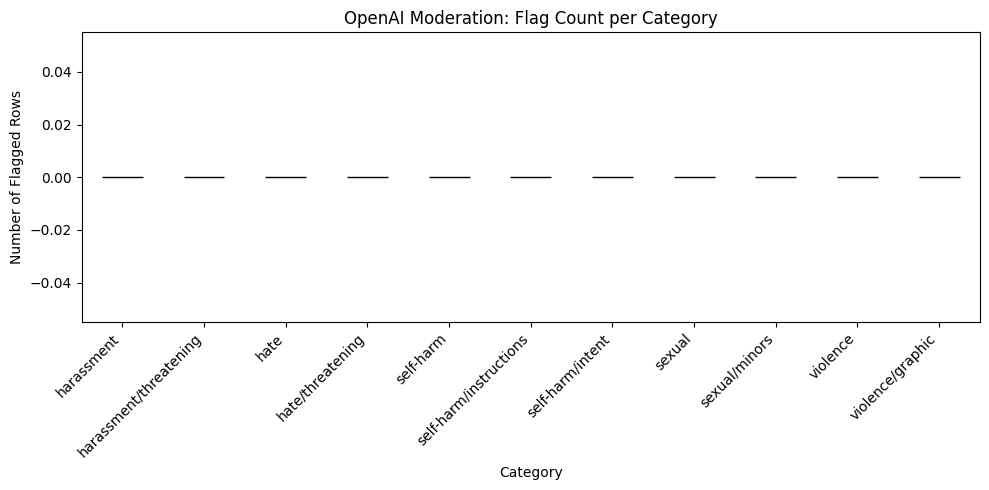

In [15]:
# Data Exploration on openai_moderation column

# Extract overall flagged
df['oai_flagged'] = df['openai_moderation'].apply(lambda x: x['flagged'])

print(df['oai_flagged'].value_counts())
print(f"Flagged rate: {df['oai_flagged'].mean():.2%}")

# Extract each category flag
categories = [
    'harassment', 'harassment/threatening', 'hate', 'hate/threatening',
    'self-harm', 'self-harm/instructions', 'self-harm/intent',
    'sexual', 'sexual/minors', 'violence', 'violence/graphic'
]

for cat in categories:
    df[f'oai_{cat}'] = df['openai_moderation'].apply(lambda x: x['categories'][cat])

print("\nFlag counts per category:")
cat_cols = [f'oai_{cat}' for cat in categories]
print(df[cat_cols].sum().sort_values(ascending=False))

# Extract category scores and summarise
for cat in categories:
    df[f'oai_score_{cat}'] = df['openai_moderation'].apply(lambda x: x['category_scores'][cat])

score_cols = [f'oai_score_{cat}' for cat in categories]
print("\nMean scores per category:")
print(df[score_cols].mean().sort_values(ascending=False).round(6))

# How many rows flagged by each source
df['toxic_roberta'] = df['toxic_chat_tag'].apply(lambda x: x['roberta-large']['flagged'])
df['toxic_t5'] = df['toxic_chat_tag'].apply(lambda x: x['t5-large']['flagged'])
df['toxic_either'] = df['toxic_roberta'] | df['toxic_t5']

print("\nFlagged rows by source:")
print(f"OpenAI moderation: {df['oai_flagged'].sum()}")
print(f"Roberta toxic tag: {df['toxic_roberta'].sum()}")
print(f"T5 toxic tag: {df['toxic_t5'].sum()}")
print(f"Either toxic tag: {df['toxic_either'].sum()}")
print(f"Any source flagged: {(df['oai_flagged'] | df['toxic_either']).sum()}")
print(f"Clean rows (none): {(~(df['oai_flagged'] | df['toxic_either'])).sum()}")

# Visualise category flag counts
flag_counts = df[cat_cols].sum().sort_values(ascending=False)
flag_counts.index = [c.replace('oai_', '') for c in flag_counts.index]

plt.figure(figsize=(10, 5))
flag_counts.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('OpenAI Moderation: Flag Count per Category')
plt.ylabel('Number of Flagged Rows')
plt.xlabel('Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

From this data exploration on the dataset with 33000 data points, it can be seen that:
1. A large majority of the data points are single turn conversations (turn = 1)
2. All 33000 data points have anony = True
3. A large majority of the data points are conversations in English (language = English)
4. 728 rows are flagged by toxic_chat_flag
5. All 33000 data points are not flagged by openai_moderation

## Data Transformation / Feature Generation

Given the information derived from the data exploration, we decided to do the following.

### 1. Drop data points and columns not needed to simplify dataset
- Drop anony column
- Drop openai_moderation column
- Drop rows where language != English (As a large majority of data points have language = English, there is not enough meaningful data to use langauge as a feature)
- Drop rows flagged by toxic_chat_tag (As only a small number of 728 data points are flagged by toxic_chat_tag, there is not enough meaningful data to use this is a feature)

### 2. Feature Engineering
- Create new column length: prompt length feature, equivalent to the character length of the prompt
- Create new column difficulty:  prompt difficulty feature, equivalent to a score created by assessing the prompts on 5 factors

In [16]:
# Extract toxicity flags from the nested 'toxic_chat_tag' column
df_transformed['toxic_roberta'] = df_transformed['toxic_chat_tag'].apply(lambda x: x['roberta-large']['flagged'])
df_transformed['toxic_t5'] = df_transformed['toxic_chat_tag'].apply(lambda x: x['t5-large']['flagged'])
# Combine the two toxicity flags into a single 'toxic_either' column
df_transformed['toxic_either'] = df_transformed['toxic_roberta'] | df_transformed['toxic_t5']

# Drop the original moderation columns that are no longer needed
df_transformed = df_transformed.drop(columns=['openai_moderation', 'toxic_chat_tag', 'anony', 'toxic_roberta', 'toxic_t5'])
print(f"After column drop: {df_transformed.shape}")

After column drop: (33000, 11)


In [17]:
# Filter to turn = 1, language = English, and non-toxic conversations
df_clean = df_transformed[
    (df_transformed['turn'] == 1) &
    (df_transformed['language'] == 'English') &
    (~df_transformed['toxic_either'])
].copy().reset_index(drop=True)

print(f"After core filtering: {df_clean.shape}")

After core filtering: (25322, 11)


In [18]:
df_bandit = df_clean.copy().reset_index(drop=True)

# Check unique models and their appearance counts
all_models = sorted(list(set(df_bandit['model_a'].unique()) | set(df_bandit['model_b'].unique())))
print(f"\nTotal unique models: {len(all_models)}")

model_counts = pd.concat([df_bandit['model_a'], df_bandit['model_b']]).value_counts()
print("\nModel appearance counts (all models):")
print(model_counts)


Total unique models: 20

Model appearance counts (all models):
vicuna-13b                 4509
koala-13b                  4254
oasst-pythia-12b           3787
gpt-3.5-turbo              3606
alpaca-13b                 3358
gpt-4                      3282
claude-v1                  3074
RWKV-4-Raven-14B           2810
chatglm-6b                 2688
fastchat-t5-3b             2476
palm-2                     2273
mpt-7b-chat                2179
stablelm-tuned-alpha-7b    2164
vicuna-7b                  2149
dolly-v2-12b               2099
claude-instant-v1          2011
llama-13b                  1567
wizardlm-13b                844
guanaco-33b                 759
gpt4all-13b-snoozy          755
Name: count, dtype: int64


After filtering to English, single-turn, and non-toxic conversations, the dataset contains 25322 remaining data points

Prompt Length

In [19]:
# Extract prompt helper
# Extract the first user message from conversation_a (prompt is the same for both conversations)
def get_first_prompt(convo):
    if isinstance(convo, str):
        convo = ast.literal_eval(convo)
    for turn in convo:
        if turn.get('role') == 'user':
            return turn.get('content', '')
    return ''

# Create prompt length feature column
df_bandit['prompt_text'] = df_bandit['conversation_a'].apply(get_first_prompt)
df_bandit['length'] = df_bandit['prompt_text'].str.len()

print(df_bandit.dtypes)
print(df_bandit.head())

question_id           str
model_a               str
model_b               str
winner                str
judge                 str
conversation_a     object
conversation_b     object
turn                int64
language              str
tstamp            float64
toxic_either         bool
prompt_text           str
length              int64
dtype: object
                        question_id           model_a           model_b  \
0  58210e39b3fd4441a2bd4a518bb44c2d        chatglm-6b         koala-13b   
1  2564acd09e3942fd97657d05282d4389  oasst-pythia-12b        alpaca-13b   
2  90bfd142157948aba01931726c888e7f         koala-13b  oasst-pythia-12b   
3  a7c5accc53e649a3bc6b2e41d962ebc4        vicuna-13b  oasst-pythia-12b   
4  adf27e819a3c494cb6e993f0c660e097        vicuna-13b         koala-13b   

    winner           judge                                     conversation_a  \
0  model_b  arena_user_973  [{'content': 'What is the difference between O...   
1      tie  arena_user_973  [{'cont

Prompt Difficulty

In [20]:
import textstat
import numpy as np

# using textstat to assess difficulty of the prompt based on readability, length, constraints, multi-step indicators, and question count

def compute_difficulty(prompt):
    prompt_lower = prompt.lower()

    # Test 1: Flesch-Kincaid grade level (readability)
    # Higher grade = harder text. Clipped to [0, 18] then normalised.
    try:
        fk_grade = textstat.flesch_kincaid_grade(prompt)
        fk_grade = max(0, min(fk_grade, 18))
    except:
        fk_grade = 0
    fk_score = fk_grade / 18.0

    # Test 2: Number of sentences (more sentences = more complex)
    # Normalised, capped at 10
    try:
        n_sentences = max(1, textstat.sentence_count(prompt))
    except:
        n_sentences = 1
    sentence_score = min(n_sentences / 10.0, 1.0)

    # Test 3: Constraint/conditional words
    constraint_words = ['but', 'however', 'must', 'except', 'unless',
                        'only if', 'without', 'constraint', 'requirement',
                        'condition', 'restrict', 'limit']
    n_constraints = sum(prompt_lower.count(w) for w in constraint_words)
    constraint_score = min(n_constraints / 5.0, 1.0)

    # Test 4: Multi-step indicators
    multistep_words = ['first', 'then', 'finally', 'step', 'next',
                       'after that', 'subsequently', 'lastly']
    n_multistep = sum(prompt_lower.count(w) for w in multistep_words)
    multistep_score = min(n_multistep / 4.0, 1.0)

    # Test 5: Number of question marks
    n_questions = prompt.count('?')
    question_score = min(n_questions / 3.0, 1.0)

    # Weighted combination
    # Score weights can be tuned if needed, current weights used are based on intuition about which signals are stronger indicators of difficulty
    difficulty = (
        0.35 * fk_score         +   # readability is strongest signal
        0.20 * sentence_score   +   # length/complexity
        0.20 * constraint_score +   # constraints add difficulty
        0.15 * multistep_score  +   # multi-step adds difficulty
        0.10 * question_score       # multiple questions
    )

    return float(np.clip(difficulty, 0.0, 1.0))

# Create prompt difficulty feature column
df_bandit['difficulty'] = df_bandit['prompt_text'].apply(compute_difficulty)

In [21]:
# Final dataset with new features
print("Dataset Overview:")
print(df_bandit.shape)
print(df_bandit.dtypes)
print(df_bandit.head())

Dataset Overview:
(25322, 14)
question_id           str
model_a               str
model_b               str
winner                str
judge                 str
conversation_a     object
conversation_b     object
turn                int64
language              str
tstamp            float64
toxic_either         bool
prompt_text           str
length              int64
difficulty        float64
dtype: object
                        question_id           model_a           model_b  \
0  58210e39b3fd4441a2bd4a518bb44c2d        chatglm-6b         koala-13b   
1  2564acd09e3942fd97657d05282d4389  oasst-pythia-12b        alpaca-13b   
2  90bfd142157948aba01931726c888e7f         koala-13b  oasst-pythia-12b   
3  a7c5accc53e649a3bc6b2e41d962ebc4        vicuna-13b  oasst-pythia-12b   
4  adf27e819a3c494cb6e993f0c660e097        vicuna-13b         koala-13b   

    winner           judge                                     conversation_a  \
0  model_b  arena_user_973  [{'content': 'What is the differ

In [22]:
# Save final dataset
df_bandit.to_json("data/df_bandit.json", orient="records", lines=True)